<a href="https://colab.research.google.com/github/Chaki34/python-basics/blob/main/%20kaggle_Froud_Dataset_Visualization%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to:
/kaggle/input/creditcardfraud

CSV files found: ['creditcard.csv']

Dataset Shape: (284807, 31)

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



================ DATASET INFORMATION ================

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
0

Dataset Shape:
(284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


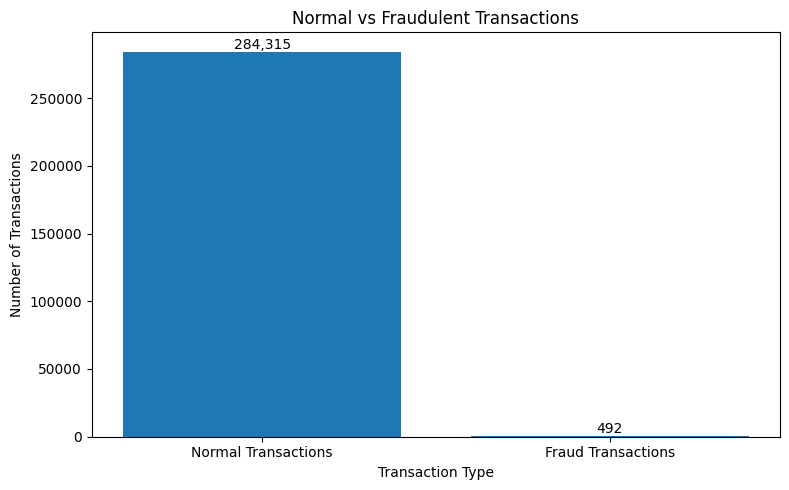


================ CLASS PERCENTAGE ================
Normal Transactions : 99.8273%
Fraud Transactions  : 0.1727%


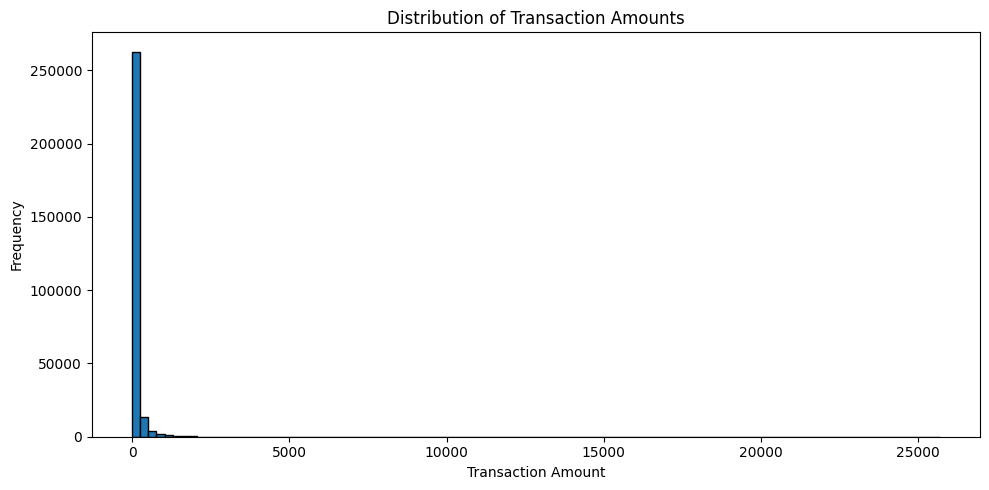

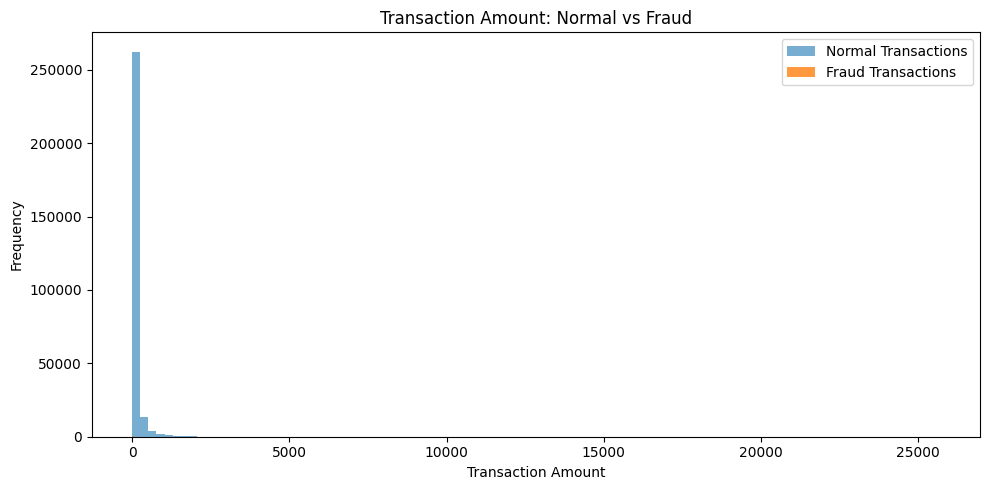

/tmp/ipykernel_671/617070841.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


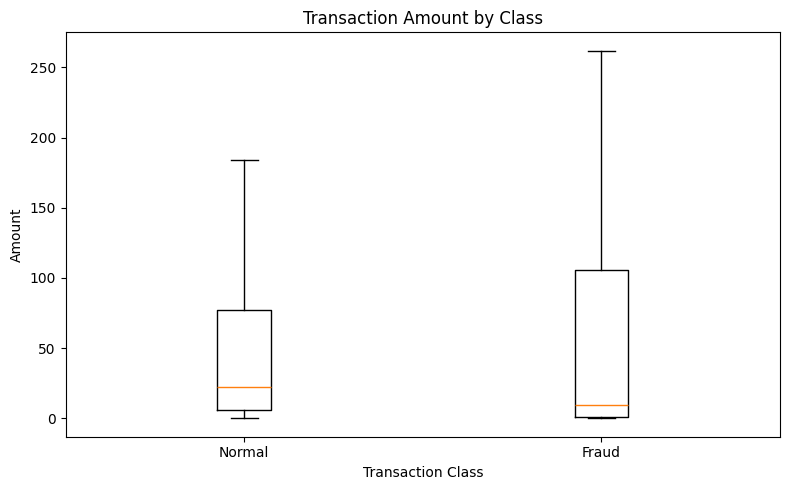

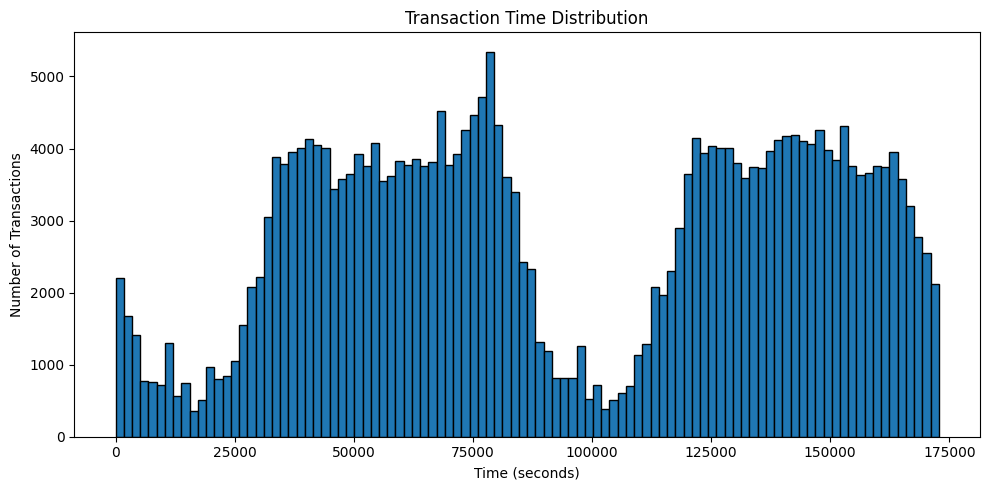

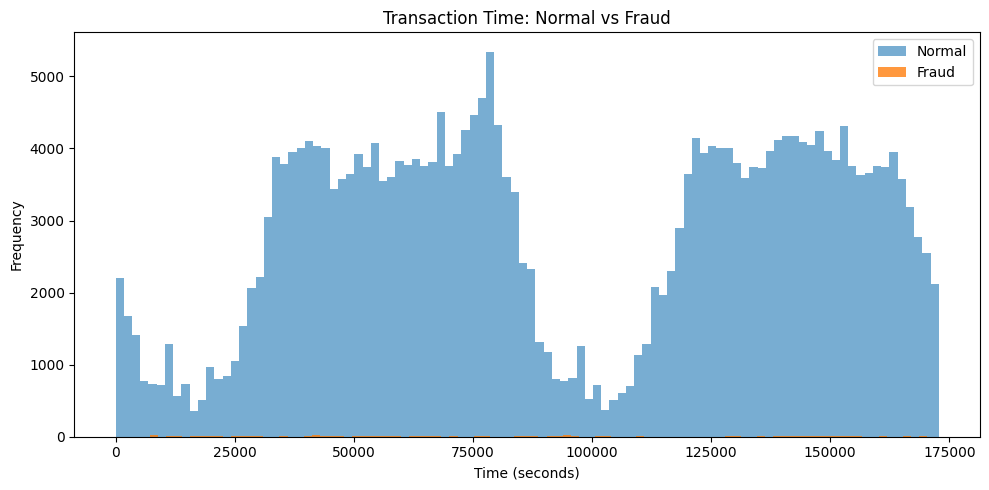

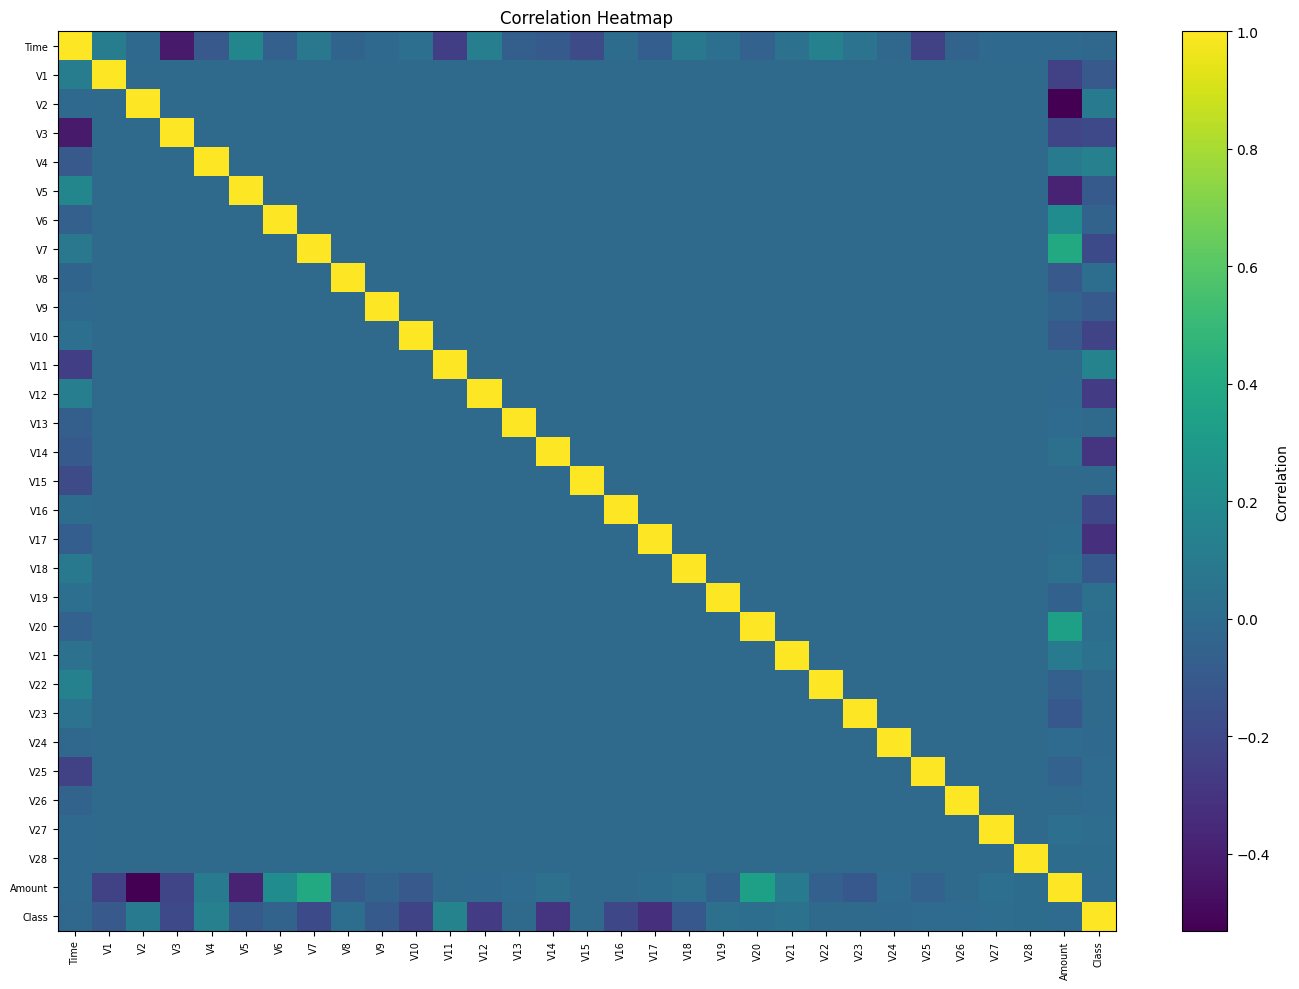

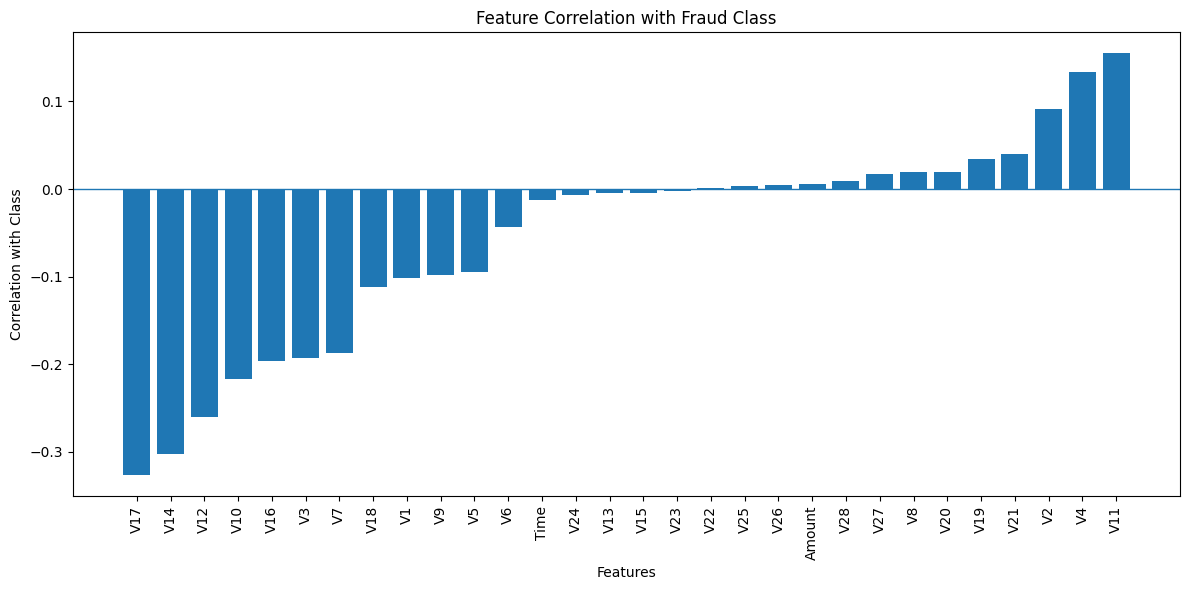


================ TOP 10 FEATURES ================
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

Performing PCA...
Explained Variance Ratio: [0.06527521 0.05612313]


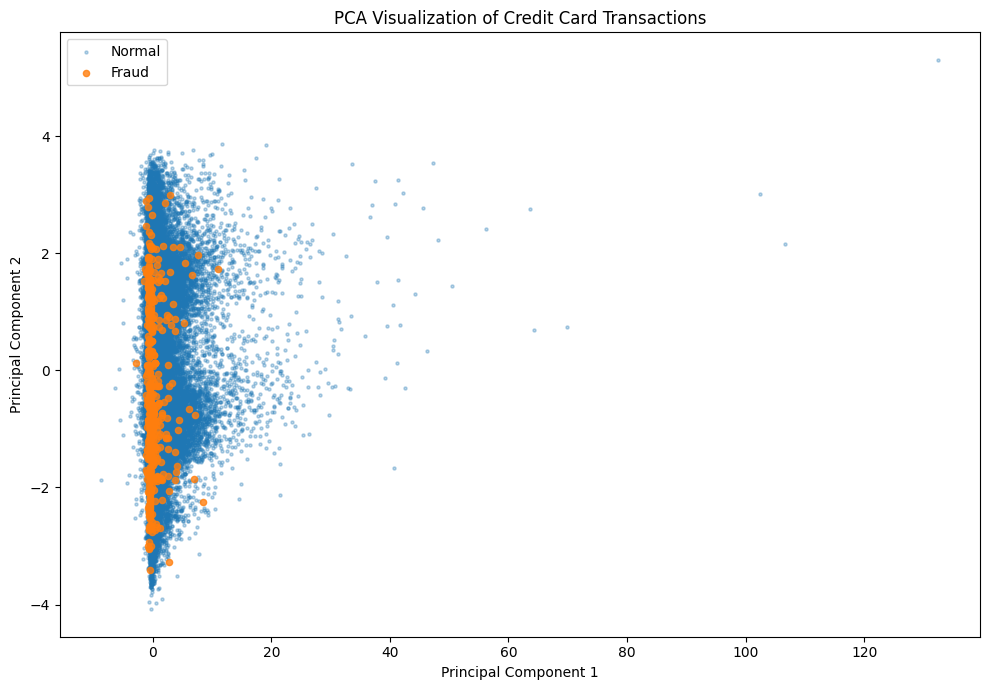


================ FRAUD TRANSACTION STATISTICS ================
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

================ NORMAL TRANSACTION STATISTICS ================
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

             CREDIT CARD FRAUD SUMMARY
Total Transactions : 284,807
Normal Transactions: 284,315
Fraud Transactions : 492
Fraud Percentage   : 0.1727%
Number of Features : 30


In [1]:
# ============================================================
# CREDIT CARD FRAUD DATASET - MATPLOTLIB VISUALIZATION
# Dataset: mlg-ulb/creditcardfraud
# ============================================================

# -----------------------------
# 1. Install / Import Libraries
# -----------------------------
!pip -q install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# ============================================================
# 2. Download Dataset
# ============================================================

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset downloaded to:")
print(path)


# ============================================================
# 3. Load Dataset
# ============================================================

import os

# Find CSV file inside downloaded directory
csv_files = [
    file for file in os.listdir(path)
    if file.endswith(".csv")
]

print("\nCSV files found:", csv_files)

# Load the first CSV file
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())


# ============================================================
# 4. Basic Dataset Information
# ============================================================

print("\n================ DATASET INFORMATION ================")

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDataset Shape:")
print(df.shape)

print("\nClass Distribution:")
print(df["Class"].value_counts())


# ============================================================
# 5. Fraud vs Normal Transactions
# ============================================================

class_counts = df["Class"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Normal Transactions", "Fraud Transactions"],
    class_counts.values
)

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6. Fraud Percentage
# ============================================================

normal_count = class_counts.get(0, 0)
fraud_count = class_counts.get(1, 0)

total = normal_count + fraud_count

normal_percentage = (normal_count / total) * 100
fraud_percentage = (fraud_count / total) * 100

print("\n================ CLASS PERCENTAGE ================")

print(f"Normal Transactions : {normal_percentage:.4f}%")
print(f"Fraud Transactions  : {fraud_percentage:.4f}%")


# ============================================================
# 7. Transaction Amount Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["Amount"],
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 8. Transaction Amount - Normal vs Fraud
# ============================================================

normal_amount = df[df["Class"] == 0]["Amount"]
fraud_amount = df[df["Class"] == 1]["Amount"]

plt.figure(figsize=(10, 5))

plt.hist(
    normal_amount,
    bins=100,
    alpha=0.6,
    label="Normal Transactions"
)

plt.hist(
    fraud_amount,
    bins=100,
    alpha=0.8,
    label="Fraud Transactions"
)

plt.title("Transaction Amount: Normal vs Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 9. Boxplot of Transaction Amount by Class
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        normal_amount,
        fraud_amount
    ],
    labels=[
        "Normal",
        "Fraud"
    ],
    showfliers=False
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")

plt.tight_layout()
plt.show()


# ============================================================
# 10. Transaction Time Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["Time"],
    bins=100,
    edgecolor="black"
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()


# ============================================================
# 11. Time Distribution - Normal vs Fraud
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["Class"] == 0]["Time"],
    bins=100,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df[df["Class"] == 1]["Time"],
    bins=100,
    alpha=0.8,
    label="Fraud"
)

plt.title("Transaction Time: Normal vs Fraud")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 12. Correlation Heatmap
# ============================================================

correlation = df.corr()

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
    fontsize=7
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


# ============================================================
# 13. Correlation of Features with Class
# ============================================================

class_correlation = (
    df.corr()["Class"]
    .drop("Class")
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.bar(
    class_correlation.index,
    class_correlation.values
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Features")
plt.ylabel("Correlation with Class")

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. Top Features Related to Fraud
# ============================================================

top_features = (
    df.corr()["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\n================ TOP 10 FEATURES ================")
print(top_features)


# ============================================================
# 15. PCA Visualization
# ============================================================

print("\nPerforming PCA...")

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Reduce to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    f"Explained Variance Ratio: "
    f"{pca.explained_variance_ratio_}"
)


# ============================================================
# 16. PCA Scatter Plot
# ============================================================

plt.figure(figsize=(10, 7))

normal = y == 0
fraud = y == 1

plt.scatter(
    X_pca[normal, 0],
    X_pca[normal, 1],
    s=5,
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    X_pca[fraud, 0],
    X_pca[fraud, 1],
    s=20,
    alpha=0.8,
    label="Fraud"
)

plt.title("PCA Visualization of Credit Card Transactions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 17. Fraud Transaction Amount Statistics
# ============================================================

print("\n================ FRAUD TRANSACTION STATISTICS ================")

print(
    df[df["Class"] == 1]["Amount"].describe()
)


# ============================================================
# 18. Normal Transaction Amount Statistics
# ============================================================

print("\n================ NORMAL TRANSACTION STATISTICS ================")

print(
    df[df["Class"] == 0]["Amount"].describe()
)


# ============================================================
# 19. Final Dataset Summary
# ============================================================

print("\n====================================================")
print("             CREDIT CARD FRAUD SUMMARY")
print("====================================================")

print(f"Total Transactions : {len(df):,}")
print(f"Normal Transactions: {normal_count:,}")
print(f"Fraud Transactions : {fraud_count:,}")

print(f"Fraud Percentage   : {fraud_percentage:.4f}%")

print(f"Number of Features : {df.shape[1] - 1}")

print("====================================================")